In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

import pickle

In [2]:
data = pd.read_csv(
    "/Users/adnanaminmir/Desktop/ADNAN_MODULE_11/car_data.csv"
)

data.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Mileage
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,18.5
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,21.0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,20.7
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0,18.9
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0,22.0


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       20 non-null     object 
 1   Year           20 non-null     int64  
 2   Selling_Price  20 non-null     float64
 3   Present_Price  20 non-null     float64
 4   Kms_Driven     20 non-null     int64  
 5   Fuel_Type      20 non-null     object 
 6   Seller_Type    20 non-null     object 
 7   Transmission   20 non-null     object 
 8   Owner          20 non-null     int64  
 9   Mileage        20 non-null     float64
dtypes: float64(3), int64(3), object(4)
memory usage: 1.7+ KB


In [4]:
data.shape

(20, 10)

In [5]:
data.describe()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner,Mileage
count,20.000000,20.000000,20.000000,20.000000,20.0,20.000000
mean,2015.850000,7.337500,10.071500,24549.050000,0.0,20.290000
std,1.899446,4.880085,6.646988,14569.561466,0.0,3.001736
min,2011.000000,2.850000,3.600000,2071.000000,0.0,14.800000
25%,2015.000000,4.125000,5.897500,11000.000000,0.0,18.725000
50%,2016.000000,6.300000,8.365000,28500.000000,0.0,20.600000
75%,2017.000000,8.237500,10.212500,35250.000000,0.0,22.175000
max,2019.000000,23.000000,32.000000,43000.000000,0.0,25.500000


In [6]:
data.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
Mileage          0
dtype: int64

In [7]:
data = data.dropna()

data.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
Mileage          0
dtype: int64

In [8]:
data = data.drop_duplicates()

data.shape

(20, 10)

In [9]:
data.columns

Index(['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Kms_Driven',
       'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner', 'Mileage'],
      dtype='object')

In [10]:
encoder = LabelEncoder()


for column in data.columns:

    if data[column].dtype == "object":

        data[column] = encoder.fit_transform(
            data[column]
        )


data.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Mileage
0,12,2014,3.35,5.59,27000,1,0,1,0,18.5
1,16,2013,4.75,9.54,43000,0,0,1,0,21.0
2,2,2017,7.25,9.85,6900,1,0,1,0,20.7
3,18,2011,2.85,4.15,5200,1,0,1,0,18.9
4,15,2014,4.60,6.87,42450,0,0,1,0,22.0


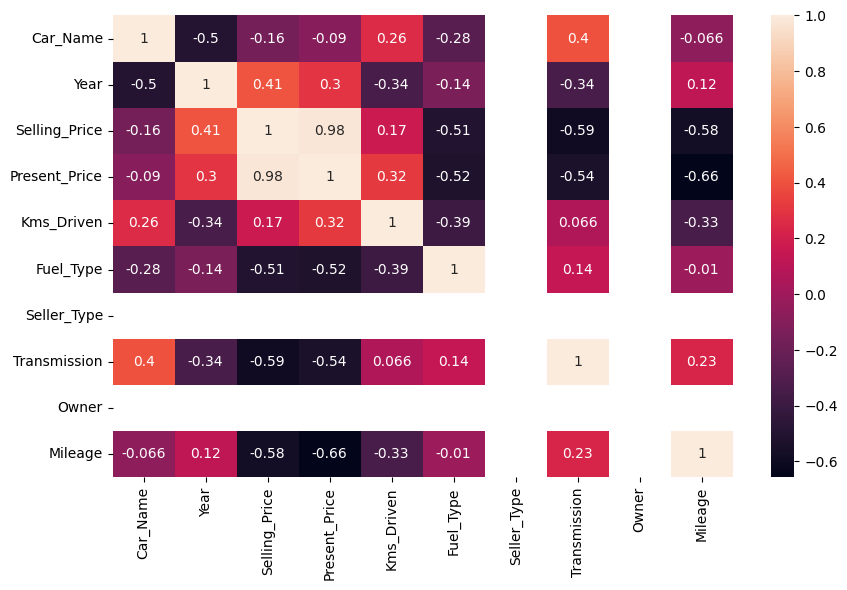

In [11]:
plt.figure(
    figsize=(10,6)
)

sns.heatmap(
    data.corr(),
    annot=True
)

plt.show()

In [12]:
X = data.drop(
    "Selling_Price",
    axis=1
)


y = data[
    "Selling_Price"
]

In [13]:
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,
    test_size=0.2,
    random_state=42

)

In [14]:
model = RandomForestRegressor(

    n_estimators=100,
    random_state=42

)

In [15]:
model.fit(

    X_train,
    y_train

)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [16]:
prediction = model.predict(

    X_test

)


prediction

array([4.0315, 4.265 , 4.1515, 7.8565])

In [17]:
score = r2_score(

    y_test,
    prediction

)


print(

    "Model Accuracy:",
    round(score*100,2),
    "%"

)

Model Accuracy: -900.04 %


In [18]:
print(

    "MAE:",
    mean_absolute_error(
        y_test,
        prediction
    )

)


print(

    "MSE:",
    mean_squared_error(
        y_test,
        prediction
    )

)

MAE: 1.0503750000000012
MSE: 2.5625904375000004


In [19]:
importance = model.feature_importances_


importance

array([0.03448808, 0.03335446, 0.68288702, 0.04428177, 0.02232612,
       0.        , 0.01701607, 0.        , 0.16564648])

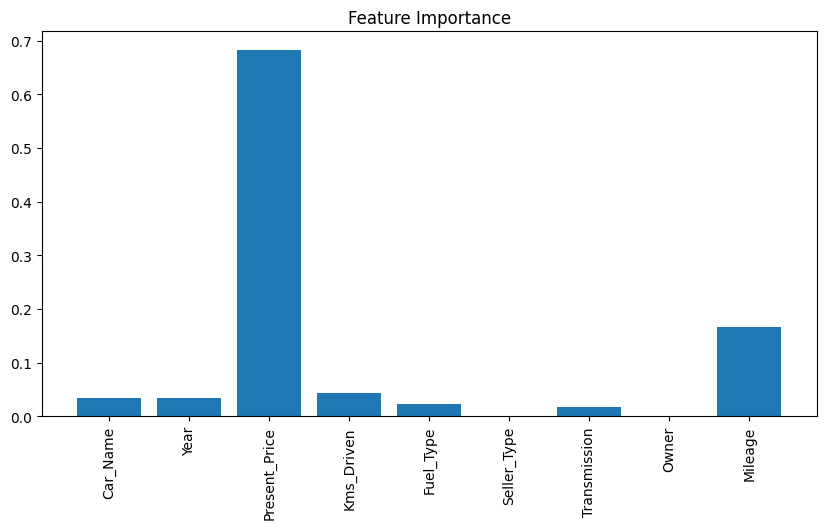

In [20]:
plt.figure(
    figsize=(10,5)
)


plt.bar(

    X.columns,
    importance

)


plt.xticks(
    rotation=90
)


plt.title(
    "Feature Importance"
)


plt.show()

In [22]:

print(X.columns)

Index(['Car_Name', 'Year', 'Present_Price', 'Kms_Driven', 'Fuel_Type',
       'Seller_Type', 'Transmission', 'Owner', 'Mileage'],
      dtype='object')


In [23]:



new_car = pd.DataFrame(
    {
        "Car_Name": [5],
        "Year": [2020],
        "Present_Price": [8.50],
        "Kms_Driven": [20000],
        "Fuel_Type": [1],
        "Seller_Type": [0],
        "Transmission": [1],
        "Owner": [0],
        "Mileage": [18.5]
    }
)


price = model.predict(
    new_car
)


print(
    "Predicted Car Price:",
    round(price[0],2),
    "Lakhs"
)

Predicted Car Price: 7.12 Lakhs


In [24]:
pickle.dump(

    model,

    open(
        "car_price_model.pkl",
        "wb"
    )

)

In [25]:
loaded_model = pickle.load(

    open(
        "car_price_model.pkl",
        "rb"
    )

)


loaded_model

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [26]:
pickle.dump(
    X.columns,
    open(
        "columns.pkl",
        "wb"
    )
)


print(
    "Columns saved successfully"
)

Columns saved successfully
